In [2]:
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier
import pandas as pd
import sys

/home/leo/Documents/geodata/weather_fixer/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# avinash CSV is: 
df = pd.read_csv("ith_2015_2025_winter_with_lake_effect.csv")
# columns are https://mesonet.agron.iastate.edu/request/download.phtml
print("Columns are: ", df.columns)


Columns are:  Index(['station', 'valid', 'tmpf', 'dwpf', 'relh', 'drct', 'sknt', 'p01i',
       'alti', 'mslp', 'vsby', 'gust', 'skyc1', 'skyc2', 'skyc3', 'skyc4',
       'skyl1', 'skyl2', 'skyl3', 'skyl4', 'wxcodes', 'ice_accretion_1hr',
       'ice_accretion_3hr', 'ice_accretion_6hr', 'peak_wind_gust',
       'peak_wind_drct', 'peak_wind_time', 'feel', 'metar', 'snowdepth',
       'year', 'month', 'date', 'lake_effect_flag'],
      dtype='object')


In [4]:
# DRY_ADIABATIC_LAPSE_RATE_C_PER_METER = -10 / 1000  # (-10C per KM)

# DRY_ADIABATIC_LAPSE_RATE_F_PER_METER = (
#     DRY_ADIABATIC_LAPSE_RATE_C_PER_METER * 1.8
# )  # per meter

# DRY_ADIABATIC_LAPSE_RATE_F_PER_FOOT = (
#     DRY_ADIABATIC_LAPSE_RATE_F_PER_METER / 3.28
# )  # per meter

# CORNELL_ELEVATION_GAIN_OVER_LAKE_FEET = 660  # feet

In [5]:
numerical_columns = [
    "tmpf",
    "dwpf",
    "relh",
    "drct",
    "sknt",
    "p01i",
    "alti",
    "mslp",
    "skyl1",
    "skyl2",
    "skyl3",
    "skyl4",
    "feel",
]

for col in numerical_columns:
    # agressively cast to numerical, pd.NaN if text
    df[col] = pd.to_numeric(df[col], errors="coerce") # this is already at 600ft elevation, at ITH airport


df.dtypes

station               object
valid                 object
tmpf                 float64
dwpf                 float64
relh                 float64
drct                 float64
sknt                 float64
p01i                 float64
alti                 float64
mslp                 float64
vsby                  object
gust                  object
skyc1                 object
skyc2                 object
skyc3                 object
skyc4                 object
skyl1                float64
skyl2                float64
skyl3                float64
skyl4                float64
wxcodes               object
ice_accretion_1hr     object
ice_accretion_3hr     object
ice_accretion_6hr     object
peak_wind_gust        object
peak_wind_drct        object
peak_wind_time        object
feel                 float64
metar                 object
snowdepth             object
year                   int64
month                  int64
date                   int64
lake_effect_flag       int64
dtype: object

In [6]:
training_df = df.drop(columns=["year", "month", "date"])

In [7]:
training_df

,station,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,mslp,...,ice_accretion_1hr,ice_accretion_3hr,ice_accretion_6hr,peak_wind_gust,peak_wind_drct,peak_wind_time,feel,metar,snowdepth,lake_effect_flag
0,ITH,2015-01-01 00:56:00,18.14,5.00,55.83,230.00,12.00,0.00,30.10,1021.20,...,M,M,M,M,M,M,4.36,KITH 010056Z 23012KT 10SM CLR M08/M15 A3010 RM...,M,0
1,ITH,2015-01-01 01:56:00,18.14,5.00,55.83,220.00,11.00,0.00,30.08,1020.40,...,M,M,M,M,M,M,4.95,KITH 010156Z 22011KT 10SM CLR M08/M15 A3008 RM...,M,0
2,ITH,2015-01-01 02:56:00,19.00,5.00,53.71,220.00,13.00,0.00,30.05,1019.30,...,M,M,M,M,M,M,4.97,KITH 010256Z 22013KT 10SM CLR M07/M15 A3005 RM...,M,0
3,ITH,2015-01-01 03:56:00,19.00,5.00,53.71,220.00,12.00,0.00,30.03,1018.70,...,M,M,M,M,M,M,5.51,KITH 010356Z AUTO 22012KT 10SM OVC065 M07/M15 ...,M,0
4,ITH,2015-01-01 04:56:00,19.00,5.00,53.71,220.00,10.00,0.00,30.00,1017.90,...,M,M,M,M,M,M,6.72,KITH 010456Z AUTO 22010G18KT 10SM OVC060 M07/M...,M,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46782,ITH,2024-12-31 19:56:00,48.00,30.00,49.49,120.00,10.00,0.00,29.65,1004.50,...,M,M,M,M,M,M,43.03,KITH 311956Z 12010G15KT 10SM BKN043 09/M01 A29...,M,0
46783,ITH,2024-12-31 20:56:00,48.00,31.00,51.54,120.00,9.00,0.00,29.65,1004.30,...,M,M,M,M,M,M,43.41,KITH 312056Z 12009G17KT 10SM FEW043 09/M01 A29...,M,0
46784,ITH,2024-12-31 21:56:00,47.00,30.00,51.39,110.00,9.00,0.00,29.63,1003.90,...,M,M,M,M,M,M,42.17,KITH 312156Z 11009KT 10SM BKN070 08/M01 A2963 ...,M,0
46785,ITH,2024-12-31 22:56:00,47.00,30.00,51.39,110.00,8.00,0.00,29.62,1003.60,...,M,M,M,M,M,M,42.59,KITH 312256Z 11008KT 10SM BKN065 OVC075 08/M01...,M,0


In [8]:
# Note, I learned some correaltion analysis techniques and examples from genai
# Point-Biserial Correlation (Best for Continuous vs Boolean)

from scipy.stats import pointbiserialr

columns_to_analyze = numerical_columns + [] # any additional columns?

results = {}

for col in numerical_columns:
    valid = training_df[[col, "lake_effect_flag"]].dropna()
    corr, p = pointbiserialr(valid["lake_effect_flag"], valid[col])
    results[col] = (corr, p)

correlation_results = pd.DataFrame(results, index=["correlation","p_value"]).T.sort_values("correlation", ascending=False)


# Interpretation:
# Positive correlation → higher values associated with lake effect
# Negative correlation → lower values associated with lake effect
correlation_results

,correlation,p_value
drct,0.22,0.00
sknt,0.17,0.00
alti,0.13,0.00
mslp,0.11,0.00
relh,0.06,0.00
p01i,-0.03,0.00
skyl1,-0.13,0.00
skyl2,-0.19,0.00
skyl3,-0.23,0.00
dwpf,-0.26,0.00


In [9]:
# Spearman Rank Correlation
# Use if relationships are nonlinear or variables contain outliers.

spearman_corr = training_df[numerical_columns + ["lake_effect_flag"]].corr(method="spearman")

spearman_corr["lake_effect_flag"].sort_values(ascending=False)

spearman_corr

,tmpf,dwpf,relh,drct,sknt,p01i,alti,mslp,skyl1,skyl2,skyl3,skyl4,feel,lake_effect_flag
tmpf,1.00,0.88,0.00,-0.14,0.03,-0.06,-0.27,-0.34,0.05,0.19,0.25,NaN,0.97,-0.29
dwpf,0.88,1.00,0.42,-0.12,-0.05,0.14,-0.37,-0.42,-0.22,0.03,0.17,NaN,0.86,-0.25
relh,0.00,0.42,1.00,-0.02,-0.22,0.44,-0.27,-0.21,-0.72,-0.48,-0.18,NaN,0.04,0.03
drct,-0.14,-0.12,-0.02,1.00,0.44,0.16,-0.07,-0.09,-0.23,-0.27,-0.30,NaN,-0.26,0.24
sknt,0.03,-0.05,-0.22,0.44,1.00,0.15,-0.21,-0.23,0.01,-0.02,-0.08,NaN,-0.20,0.16
p01i,-0.06,0.14,0.44,0.16,0.15,1.00,-0.32,-0.29,-0.45,-0.38,-0.20,NaN,-0.10,0.25
alti,-0.27,-0.37,-0.27,-0.07,-0.21,-0.32,1.00,1.00,0.18,0.06,-0.08,NaN,-0.22,0.13
mslp,-0.34,-0.42,-0.21,-0.09,-0.23,-0.29,1.00,1.00,0.15,0.02,-0.08,NaN,-0.28,0.11
skyl1,0.05,-0.22,-0.72,-0.23,0.01,-0.45,0.18,0.15,1.00,0.78,0.57,NaN,0.06,-0.14
skyl2,0.19,0.03,-0.48,-0.27,-0.02,-0.38,0.06,0.02,0.78,1.00,0.78,NaN,0.20,-0.21


In [10]:
from sklearn.feature_selection import mutual_info_classif


# following print: every column has null, so cant just drop na
# print(training_df[numerical_columns + ["lake_effect_flag"]].isna().sum().sort_values(ascending=False))

mutual_info_classif_columns = list(filter(lambda x : x != "skyl4" , numerical_columns)) # drop column that is all nans

X = training_df[mutual_info_classif_columns].fillna(training_df[mutual_info_classif_columns].median()) # otherwise no row is valid
y = training_df["lake_effect_flag"]

mi = mutual_info_classif(X, y)

mi_series = pd.Series(mi, index=mutual_info_classif_columns).sort_values(ascending=False)

# Higher MI → stronger relationship.
print(mi_series)

feel    0.07
tmpf    0.06
relh    0.06
dwpf    0.05
drct    0.04
skyl1   0.03
p01i    0.03
skyl2   0.02
sknt    0.02
skyl3   0.01
alti    0.01
mslp    0.01
dtype: float64


In [18]:
# Group Mean Comparison (Simple but Insightful)
grouped_mean = training_df.groupby("lake_effect_flag")[numerical_columns].mean() # lake effect vs not lake effect
grouped_mean

,tmpf,dwpf,relh,drct,sknt,p01i,alti,mslp,skyl1,skyl2,skyl3,skyl4,feel
lake_effect_flag,,,,,,,,,,,,,
0,31.96,25.19,77.73,202.54,8.09,0.00,30.00,1017.96,2725.84,3771.10,4605.90,NaN,25.08
1,15.26,10.68,81.94,304.72,12.09,0.00,30.15,1022.91,1491.71,2239.58,3050.91,NaN,1.28


For categorical features with a binary target, Pearson correlation isn't appropriate. You want Cramér's V, which measures association between categorical variables using the chi-squared statistic. It ranges from 0 (no association) to 1 (perfect association).

In [22]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = len(x)
    k = min(table.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else 0

def bias_corrected_cramers_v(x, y): # use when many unique values in feature
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = len(x)
    k = min(table.shape) - 1
    r, k_rows, k_cols = table.shape[0], table.shape[0], table.shape[1]
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - (k_rows - 1) * (k_cols - 1) / (n - 1))
    k_rows_corr = k_rows - (k_rows - 1)**2 / (n - 1)
    k_cols_corr = k_cols - (k_cols - 1)**2 / (n - 1)
    denom =  min(k_rows_corr - 1, k_cols_corr - 1)
    if denom <= 0:
        return 0.0 # constant column
    return np.sqrt(phi2_corr / denom)


categorical_columns = training_df.columns.difference(numerical_columns)

# compute Cramér's V for each feature against Y
results = {col: cramers_v(training_df[col], training_df["lake_effect_flag"]) for col in categorical_columns if col != "lake_effect_flag"}

corr = pd.Series(results).sort_values(ascending=False)
print(corr)

print("\nBIAS CORRECTED:")
# compute bias corrected Cramér's V for each feature against Y
bias_corrected_results = {col: bias_corrected_cramers_v(training_df[col], training_df["lake_effect_flag"]) for col in categorical_columns if col != "lake_effect_flag"}

bias_corrected_corr = pd.Series(bias_corrected_results).sort_values(ascending=False)
print(bias_corrected_corr)

metar               1.00
valid               1.00
wxcodes             0.44
peak_wind_time      0.43
vsby                0.30
peak_wind_drct      0.16
gust                0.14
skyc1               0.12
peak_wind_gust      0.12
skyc2               0.09
skyc3               0.08
ice_accretion_6hr   0.00
ice_accretion_1hr   0.00
ice_accretion_3hr   0.00
skyc4               0.00
snowdepth           0.00
station             0.00
dtype: float64

BIAS CORRECTED:
wxcodes             0.44
peak_wind_time      0.36
vsby                0.30
peak_wind_drct      0.16
gust                0.14
skyc1               0.12
peak_wind_gust      0.12
skyc2               0.09
skyc3               0.07
valid               0.01
ice_accretion_3hr   0.00
ice_accretion_6hr   0.00
metar               0.00
ice_accretion_1hr   0.00
skyc4               0.00
snowdepth           0.00
station             0.00
dtype: float64


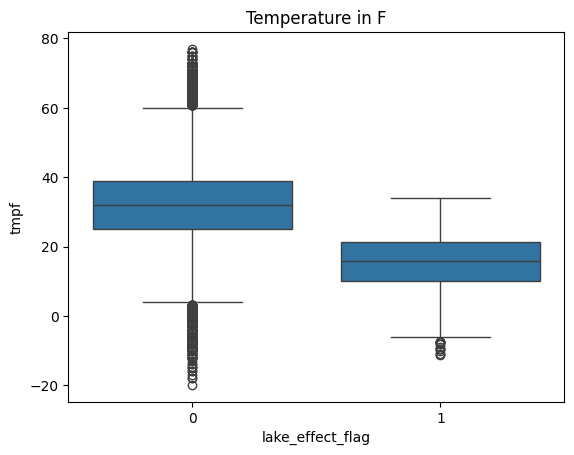

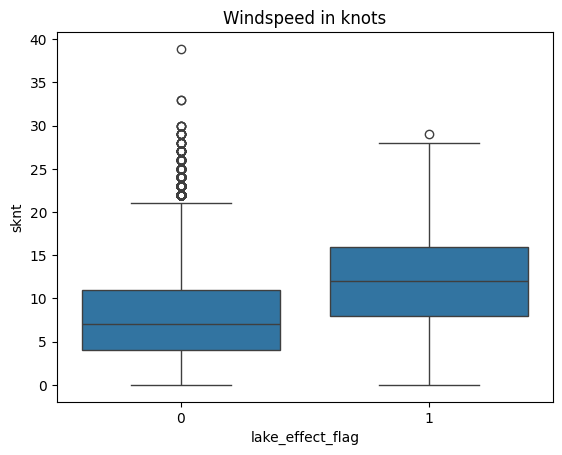

In [12]:
# visual version of grouped mean? 
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=training_df, x="lake_effect_flag", y="tmpf")
plt.title("Temperature in F")
plt.show()

sns.boxplot(data=training_df, x="lake_effect_flag", y="sknt")
plt.title("Windspeed in knots")
plt.show()

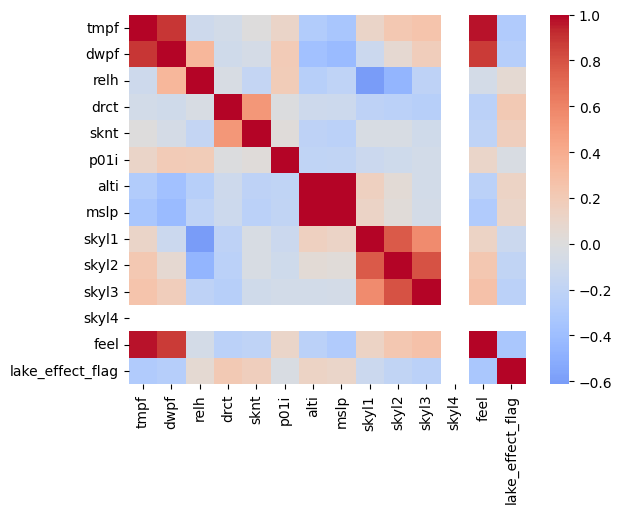

In [13]:
#  correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plain_corr = training_df[numerical_columns + ["lake_effect_flag"]].corr(method="pearson") # and now investigate into different correlation methods 

sns.heatmap(plain_corr, cmap="coolwarm", center=0)
plt.show()

# TODO: need to interpret this proprly, see https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html